In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image


%matplotlib inline

# Tarea 3

Instrucciones

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a juancaros@udec.cl el dia 6/6 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos junaeb3.csv, el diccionario de datos es el siguiente:

sexo: sexo del estudiante (1: mujer)
edad: edad del estudiante (meses)
imce: indice de masa corporal estandarizado (puntaje z)
vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
area: urbana=1, rural=0
sk1: muestra afecto a padres (1: siempre - 5: nunca)
sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
sk3: expresa sus sentimientos (1: siempre - 5: nunca)
sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
sk5: juega con otros (1: siempre - 5: nunca)
sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
sk7: es agresivo (1: siempre - 5: nunca)
sk8: participa en juegos grupales (1: siempre - 5: nunca)
sk9: hace preguntas a adultos (1: siempre - 5: nunca)
sk10: tiene interes por libros (1: siempre - 5: nunca)
sk11: tiene interes por su entorno (1: siempre - 5: nunca)
sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca)
sk13: tiene expresiones artisticas (1: siempre - 5: nunca)
act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
educm: años de escolaridad de la madre
educp: años de escolaridad del padre
madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

# Carga de datos

Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

**R**: Se cargo la data y se visualizo la información de los datos, se generó un heatmap para apreciar los datos faltantes de cada variables, en este caso son bastantes pocos, el que tiene mayores datos faltantes es act_fisica, por lo que se reemplazaron por la moda de esta variables, se vieron algunos outliers, pero no son de gran significancia, luego se dropearon los valores faltantes y se dropeo la columna sk7 por inconsistencia en la data.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/juancaros/LAB-MAA/refs/heads/main/data/junaeb3.csv')
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,...,2,3,2,1,3,NaN,1,13.0,13,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
dtype: object
               sexo          edad          imce    vive_padre    vive_madre  \
count  31055.000000  31055.000000  31055.000000  31055.000000  31055.000000   
mean       0.538979     82.589084      1.017787      0.720335      0.966511   
std        0.498486      4.360270      1.370552      0.449415      0.189671   
min        0.000000     62.000000     -5.020000      0.000000      0.000000   
25%        0.000000     80.000000      0.120000      0.000000      1.000000   
50%   

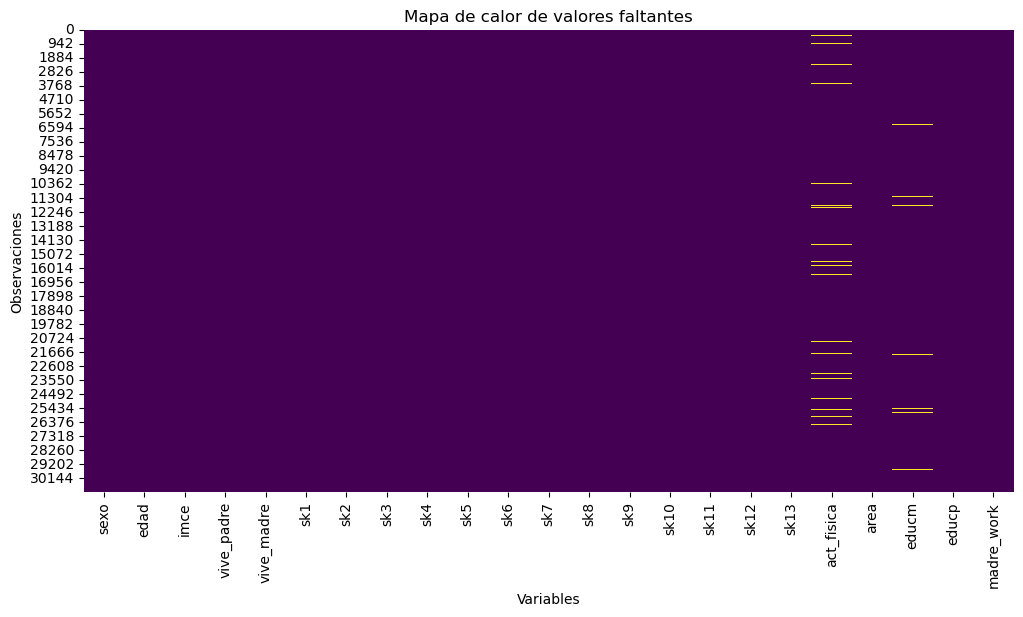

act_fisica    0.032330
educm         0.012011
sexo          0.000000
sk8           0.000000
educp         0.000000
area          0.000000
sk13          0.000000
sk12          0.000000
sk11          0.000000
sk10          0.000000
sk9           0.000000
sk7           0.000000
edad          0.000000
sk6           0.000000
sk5           0.000000
sk4           0.000000
sk3           0.000000
sk2           0.000000
sk1           0.000000
vive_madre    0.000000
vive_padre    0.000000
imce          0.000000
madre_work    0.000000
dtype: float64


In [3]:
print(df.dtypes)
print(df.describe(include='all'))

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores faltantes')
plt.xlabel('Variables')
plt.ylabel('Observaciones')
plt.show()

print(df.isnull().mean().sort_values(ascending=False))


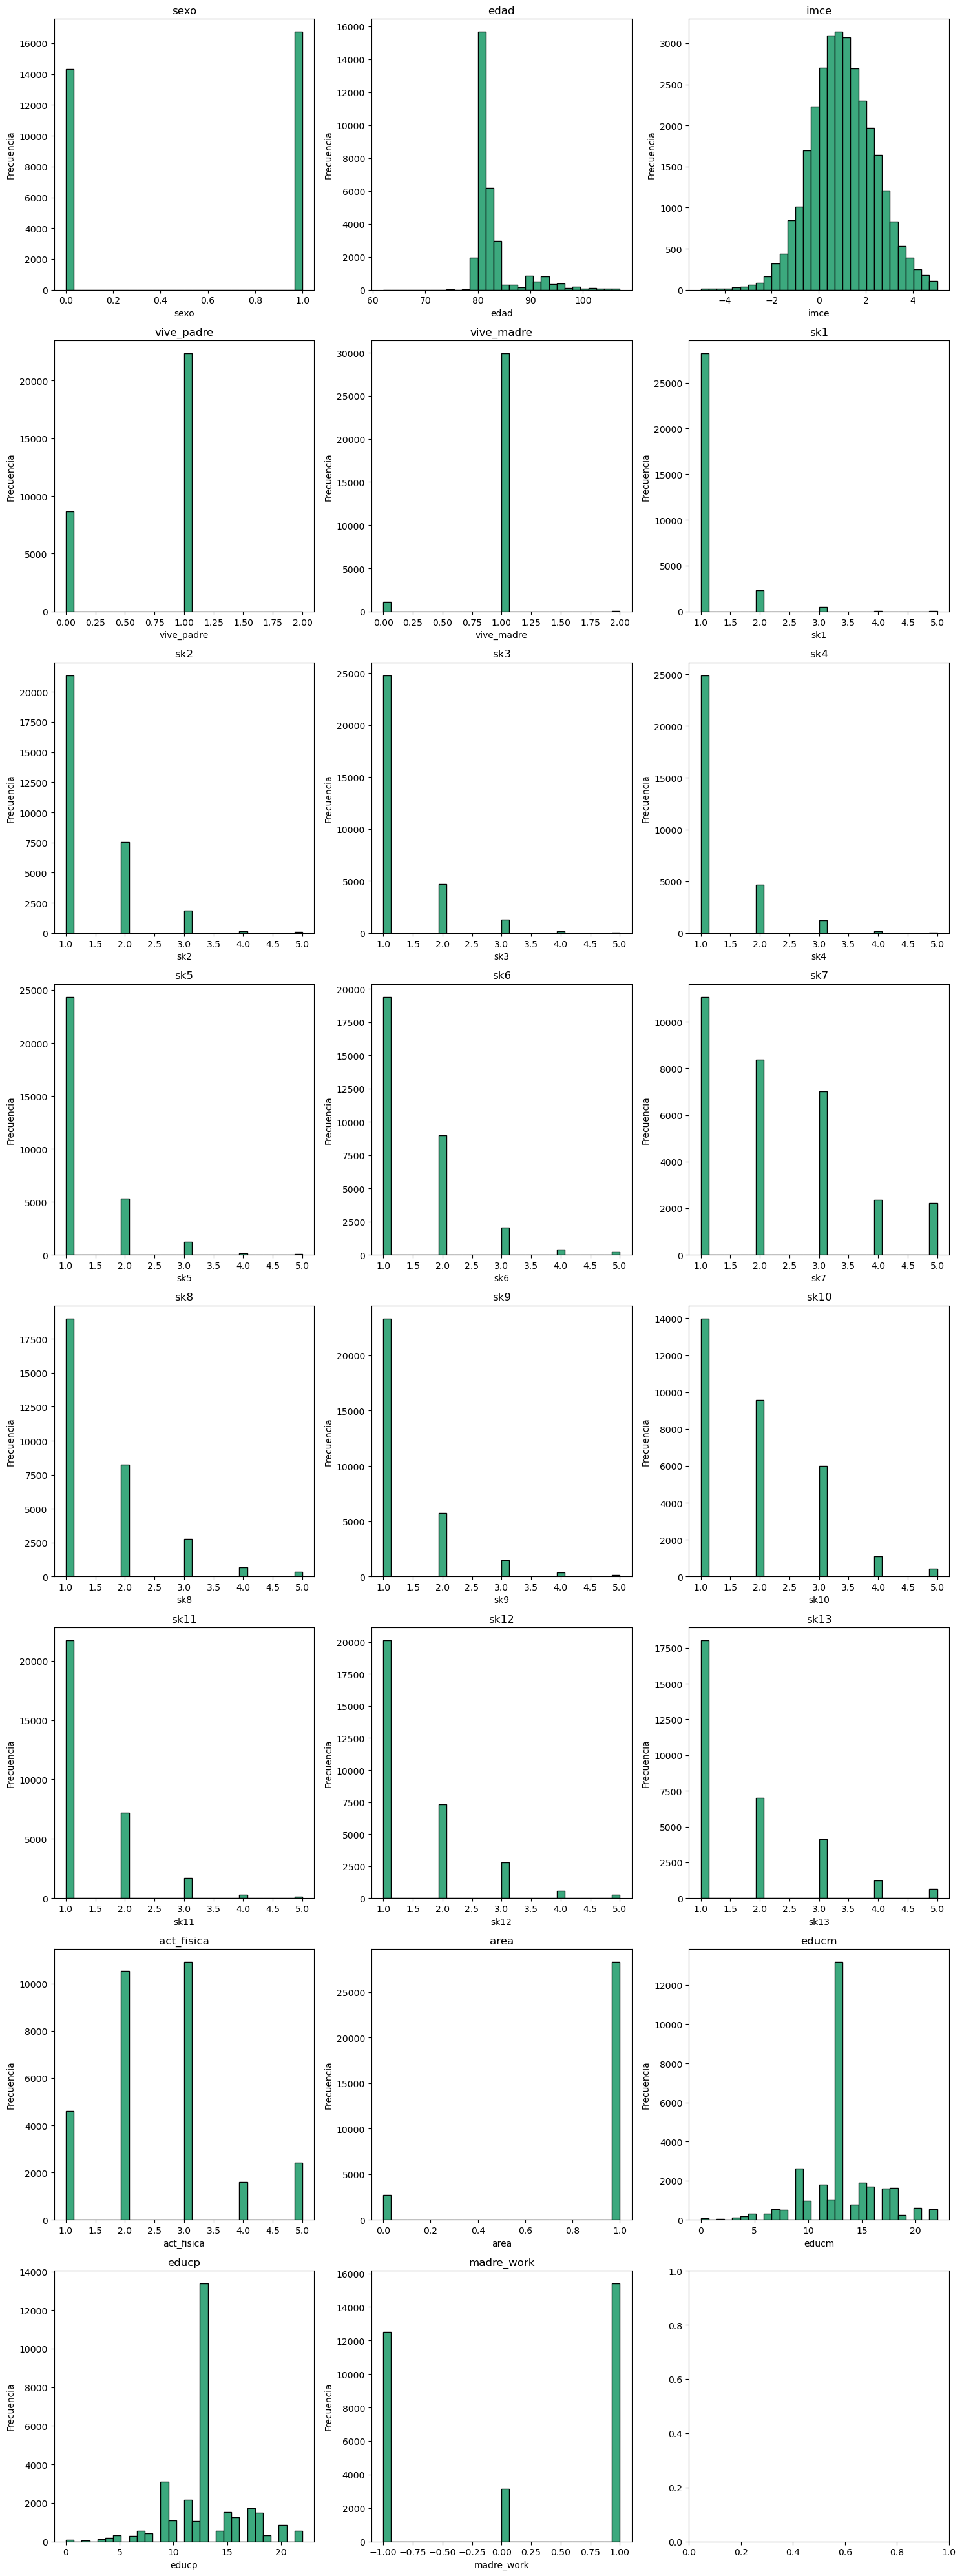

In [4]:
numerical_columns = df.select_dtypes(include='number').columns;
num_columns = len(numerical_columns);
fig, axs = plt.subplots((num_columns + 2) // 3, 3, figsize=(15, (num_columns + 2) // 3 * 5));
for i, column in enumerate(numerical_columns):
    ax = axs[i // 3, i % 3];
    ax.hist(df[column], bins=30, color='#3CA97E', edgecolor='black');
    ax.set_title(f'{column}');
    ax.set_xlabel(column);
    ax.set_ylabel('Frecuencia');
plt.tight_layout();
plt.show()

In [5]:
# Completar con la moda
df['act_fisica'] = df['act_fisica'].fillna(df['act_fisica'].mode()[0])

print(df[['act_fisica', 'educm', 'educp']].isnull().sum())


act_fisica      0
educm         373
educp           0
dtype: int64


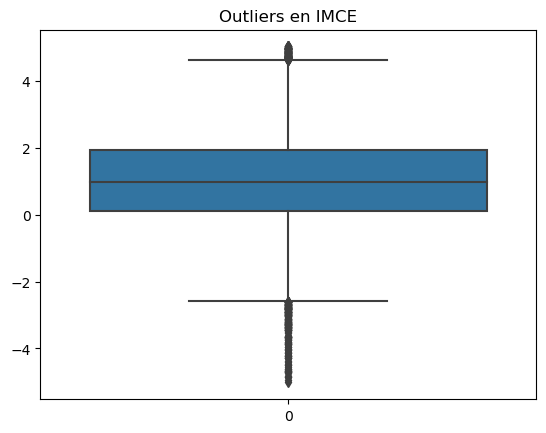

In [6]:
sns.boxplot(df['imce'])
plt.title("Outliers en IMCE")
plt.show()


In [7]:
df=df.dropna()

In [8]:
df1 = df.loc[:, 'sk1':'sk13']
df1 = df1.drop('sk7', axis=1)


# EFA

A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

**R**: A partir del EFA, realizado a las variables sk1 a sk13, exlcuyendo sk7, se identificó una estructura de tres factores latentes, determinados segun el criterio de autovalores mayores a 1. El primer factor agrupa variables como sk9 a sk13 y se asocia a comportaminetos sociales y de participación, por lo que se interpretó como Relaciones Solaciales. El segundo esta compuesto por sk1 a sk4, y refleja los aspectos fisícos o de autocuidado, por lo que se le denominó Salud Física. El tercer dactos incluye sk5, sk6 y sk8, y se relacionan con estados emocionales, por lo que se interpretó como Bienestar Psicológico. En general se identificó un número optimo de 3 factores 

In [9]:
fa = FactorAnalyzer(rotation='varimax').fit(df1)

np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.185313, 0.555585, 0.127311],
       [0.185578, 0.529404, 0.320400],
       [0.184688, 0.597392, 0.153118],
       [0.200571, 0.689812, 0.180414],
       [0.126267, 0.232137, 0.761099],
       [0.184596, 0.231516, 0.441430],
       [0.281679, 0.120480, 0.465823],
       [0.500816, 0.218841, 0.189721],
       [0.563680, 0.128299, 0.108960],
       [0.670413, 0.215719, 0.183687],
       [0.529548, 0.120146, 0.134142],
       [0.486402, 0.156528, 0.121785]])

In [10]:
fa.get_eigenvalues()

(array([4.076705, 1.341095, 1.077694, 0.792859, 0.736064, 0.698040,
        0.685635, 0.607242, 0.525768, 0.513719, 0.488150, 0.457029]),
 array([3.494762, 0.748433, 0.538200, 0.162610, 0.097439, 0.031049,
        0.007770, -0.008382, -0.042614, -0.058979, -0.081491, -0.107403]))

In [11]:
fa.get_communalities()

array([0.359223, 0.417365, 0.414432, 0.548619, 0.649103, 0.282536,
       0.310850, 0.334702, 0.346068, 0.529729, 0.312850, 0.275920])

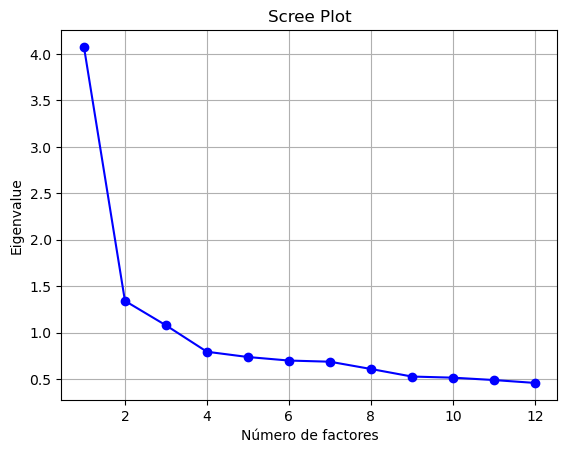

In [12]:
fa = FactorAnalyzer(rotation=None)
fa.fit(df1)

ev, v = fa.get_eigenvalues()

plt.figure()
plt.plot(range(1, df1.shape[1] + 1), ev, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Número de factores')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()


In [13]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(df1)

loadings = pd.DataFrame(fa.loadings_, index=df1.columns)
print(loadings)

             0         1         2
sk1   0.185313  0.555585  0.127311
sk2   0.185578  0.529404  0.320400
sk3   0.184688  0.597392  0.153118
sk4   0.200571  0.689812  0.180414
sk5   0.126267  0.232137  0.761099
sk6   0.184596  0.231516  0.441430
sk8   0.281679  0.120480  0.465823
sk9   0.500816  0.218841  0.189721
sk10  0.563680  0.128299  0.108960
sk11  0.670413  0.215719  0.183687
sk12  0.529548  0.120146  0.134142
sk13  0.486402  0.156528  0.121785


In [14]:
fa.get_factor_variance()

(array([1.807495, 1.693486, 1.280415]),
 array([0.150625, 0.141124, 0.106701]),
 array([0.150625, 0.291748, 0.398450]))

In [15]:
communalities = fa.get_communalities()
com_df = pd.DataFrame({'Variable': df1.columns, 'Comunalidad': communalities})
print(com_df.sort_values(by='Comunalidad'))


   Variable  Comunalidad
11     sk13     0.275920
5       sk6     0.282536
6       sk8     0.310850
10     sk12     0.312850
7       sk9     0.334702
8      sk10     0.346068
0       sk1     0.359223
2       sk3     0.414432
1       sk2     0.417365
9      sk11     0.529729
3       sk4     0.548619
4       sk5     0.649103


# Gráficos 

Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

**R**: Los gráficos muestran diferencias en la distribución de los factores según las variables analizadas. Para sexo, se observan ligeras variaciones, con mayor concetraciónn de mujeres en valores medios-altos del Factor 1, y mayor despersión en hombres para el Factor 3.Respecto al IMCE es dificil notar una tendencia en los Factores por el tipo de gráfico, pero se esperaría que los estudiantes con alto rendimiento tiendan a agruparse en altos valores de Factor 1 y bajos de Factor 3. Los mismo pasa con actividad física, pero se espera que la relación sea mas estable para el Factoe 1 y 3, y en el 2 sea menos claro.

In [16]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(df1)
factor_scores = fa.transform(df1)
df_factors = pd.DataFrame(factor_scores, columns=['Factor1', 'Factor2', 'Factor3'])

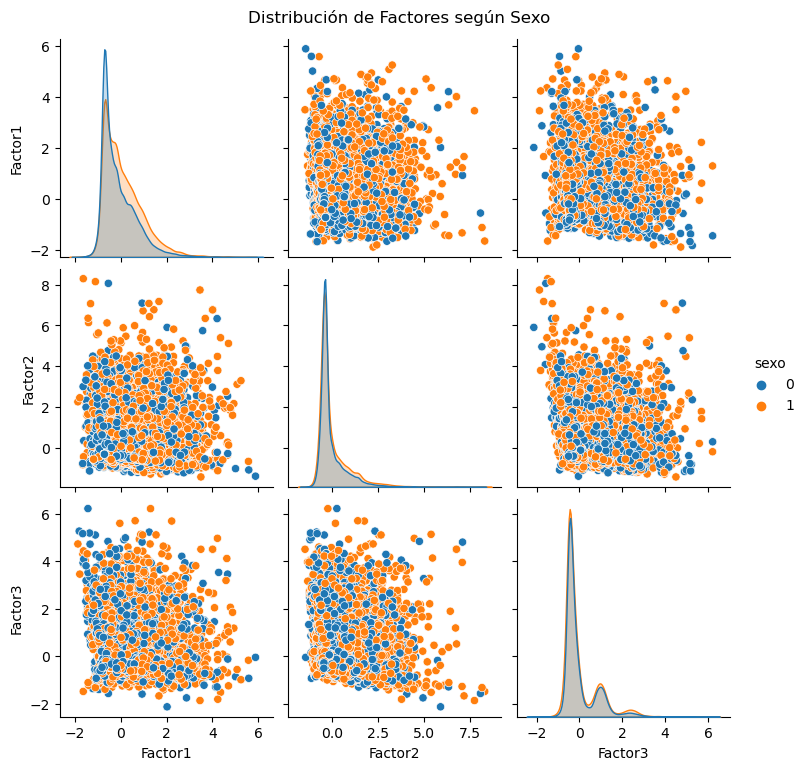

In [17]:
#Grafica sexo
df_plot = pd.concat([df[['sexo', 'area', 'imce', 'act_fisica']].reset_index(drop=True), df_factors], axis=1)
sns.pairplot(df_plot, hue='sexo', vars=['Factor1', 'Factor2', 'Factor3'])
plt.suptitle("Distribución de Factores según Sexo", y=1.02)
plt.show()


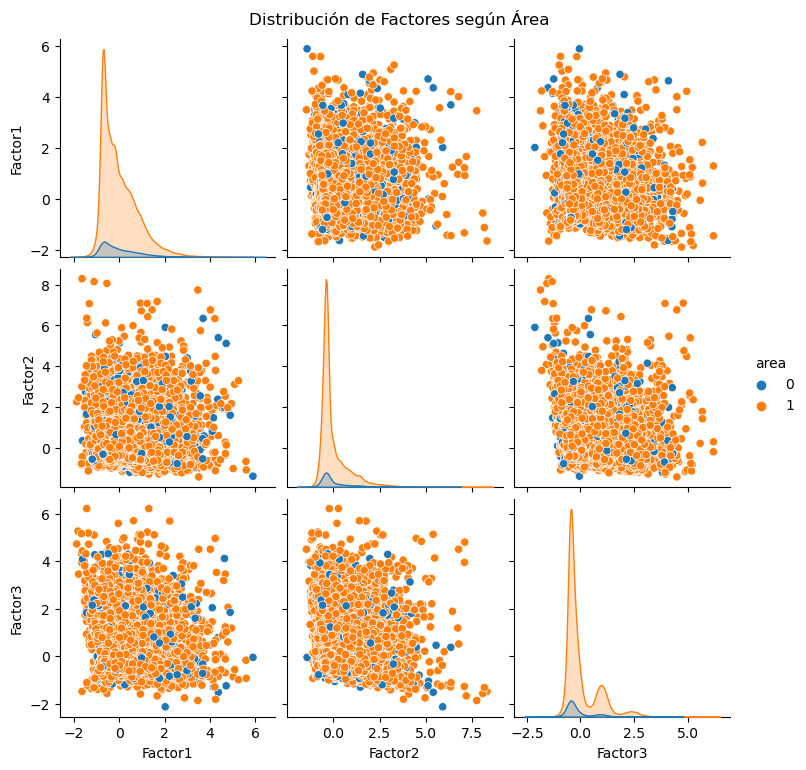

In [18]:
#Grafica Área
sns.pairplot(df_plot, hue='area', vars=['Factor1', 'Factor2', 'Factor3'])
plt.suptitle("Distribución de Factores según Área", y=1.02)
plt.show()


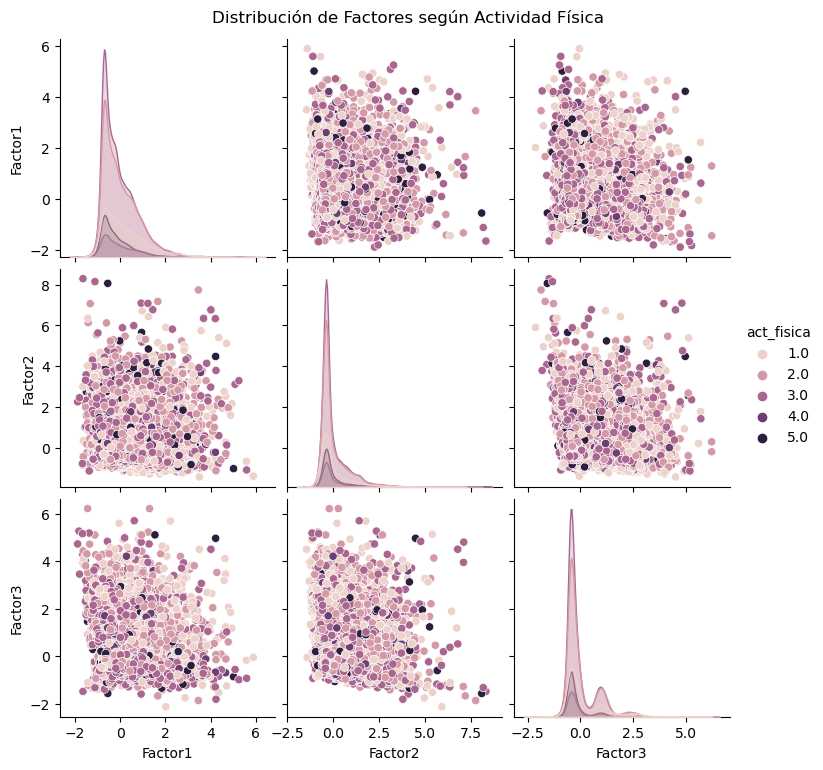

In [19]:
#Gráfica Actividad Física 
sns.pairplot(df_plot.dropna(subset=['act_fisica']), hue='act_fisica', vars=['Factor1', 'Factor2', 'Factor3'])
plt.suptitle("Distribución de Factores según Actividad Física", y=1.02)
plt.show()


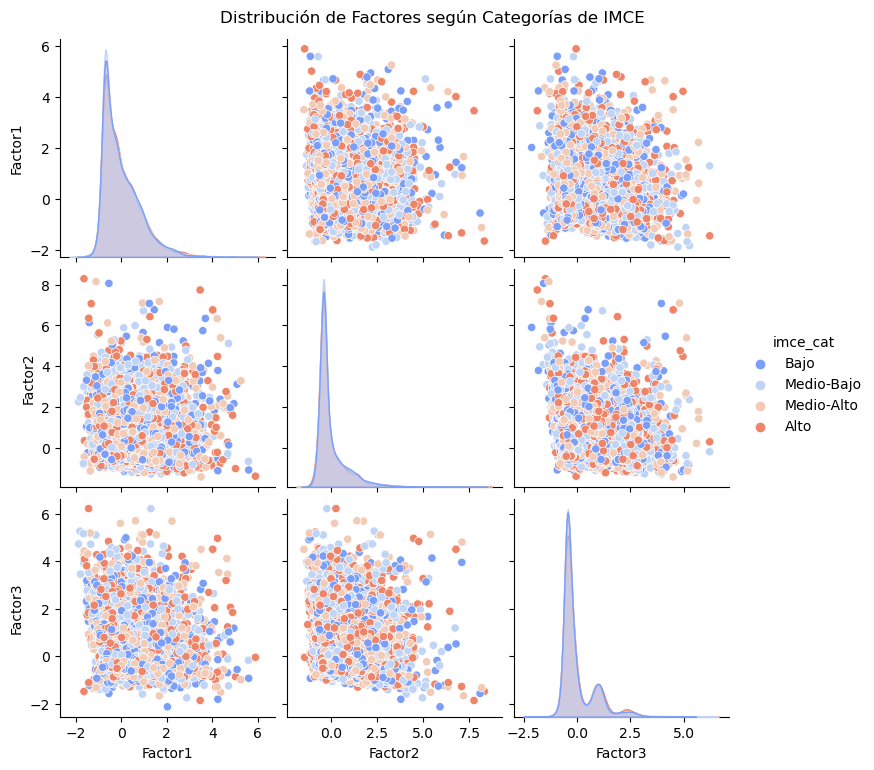

In [20]:
# Gráfica IMCE
df_plot['imce_cat'] = pd.qcut(df_plot['imce'], q=4, labels=["Bajo", "Medio-Bajo", "Medio-Alto", "Alto"])
sns.pairplot(df_plot.dropna(subset=['imce_cat']), hue='imce_cat', vars=['Factor1', 'Factor2', 'Factor3'], palette='coolwarm')
plt.suptitle("Distribución de Factores según Categorías de IMCE", y=1.02)
plt.show()


# CFA

Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings).

**R**: En base a los resultados obtenidos en la pregunta 2, se propuso un CFA con tres factores, en el que cada variables se asocia exclusivamente a uno de ellos. El factor 1, llamado Habilidades emocionales y sociales,  agrupa las variables sk8,sk9,sk10,sk11 y sk12, con cargas estandarizadas entre 0.44 y 0.73. El factor 2, denominado Autoeficacia académica, incluye las variables sk2,sk3,sk4,sk5 y sk6, con cargas que van desde 0.47 a 0.69. Por utlimo el factor 3, denominado Regulacion personal, está compuesto por las variables sk1 y sk13, cn cargas estandarizadas de 0,47 y 0.4 respectivamnete, Las correlaciones entre factores fueron altas, especialmente entre el factor 1 y el factor 3 (0.97), lo que sugiere una estrecha relación conceptual entre habilidades emocionales y regulación personal. El modelo presentó un ajuste rasonable (CFI = 0.87, RMSEA = 0.083), lo que respalda parcialmente la estructura propuesta.

In [21]:
print(semopy.efa.explore_cfa_model(df1, pval=0.05))

eta1 =~ sk11 + sk9 + sk10 + sk12
eta2 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk6 + sk8 + sk12
eta3 =~ sk11 + sk12 + sk13



In [47]:
model_desc = """
Factor1 =~ sk9 + sk10 + sk11 + sk12
Factor2 =~ sk2 + sk3 + sk4 + sk5 + sk6
Factor3 =~ sk1 + sk13
"""
model = semopy.Model(model_desc)
out=model.fit(df1)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.241
Number of iterations: 39
Params: 1.305 1.252 1.069 0.858 0.950 0.721 0.829 2.067 0.161 0.107 0.072 0.178 0.086 0.035 0.119 0.607 0.193 0.452 0.817 0.243 0.210 0.172 0.226 0.427 0.280


In [48]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Factor1,1.000000,0.603939,-,-,-
1,sk10,~,Factor1,1.304866,0.557375,0.017698,73.728139,0.0
2,sk11,~,Factor1,1.252303,0.752443,0.014468,86.554446,0.0
3,sk12,~,Factor1,1.068784,0.537294,0.014888,71.789134,0.0
4,sk2,~,Factor2,1.000000,0.649735,-,-,-
5,sk3,~,Factor2,0.857579,0.619087,0.010002,85.739381,0.0
6,sk4,~,Factor2,0.950351,0.694367,0.010237,92.837376,0.0
7,sk5,~,Factor2,0.720890,0.538216,0.00939,76.77408,0.0
8,sk6,~,Factor2,0.828630,0.471477,0.01207,68.652654,0.0
9,sk1,~,Factor3,1.000000,0.476956,-,-,-


In [49]:
semopy.calc_stats(model)


,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,41,55,7407.536187,0.0,77708.140392,0.905135,0.904675,0.872125,0.904675,0.872743,0.076525,49.517141,257.802927,0.241429


# Clase Latente

Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

**R**: El análisis de clases latentes usando StepMix identificó que el numero optimo de clases es 4, basado en el criterio del BIC, en el gráfico se aprecia que el menor valor de BIC corresponede a 4 clases. Las calses identificadas difieren bastante en los valroes promedios del IMCE, mostrando grupos con persepciones variadas del clima escolar, desde muy bueno hasta malo. En el gráfico de clusters se puede pareciar la diferencia entre ellos.

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.88s/it, max_LL=-5.36e+4, max_avg_LL=-1.75]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.77s/it, max_LL=-5.31e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 1/1 [00:21<00:00, 21.91s/it, max_LL=-5.31e+4, max_avg_LL=-1.73]
C:\Users\carmi\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:24<00:00, 24.61s/it, max_LL=-5.31e+4, max_avg_LL=-1.73]
C:\Users\carmi\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:24<00:00, 24.51s/it, max_LL=-5.31e+4, max_avg_LL=-1.73]
C:\Users\carmi\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


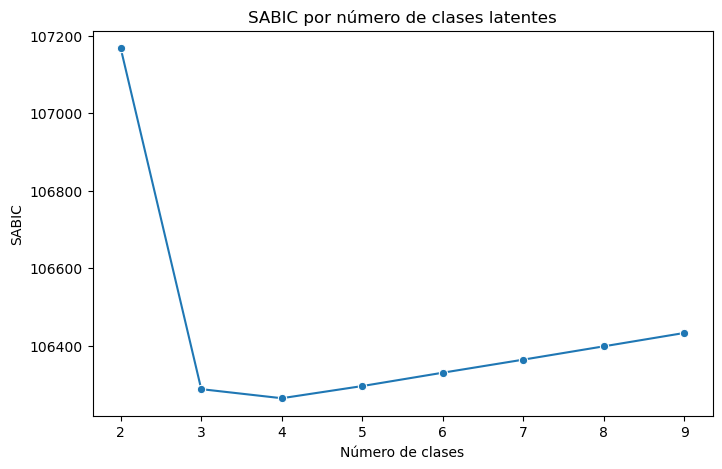

In [53]:
from stepmix.stepmix import StepMix

df_step = df[['imce']].dropna().reset_index(drop=True)

K = range(2, 10)
fits = []
bic_scores = []

for k in K:
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123)
    model.fit(df_step)
    fits.append(model)
    bic_scores.append(model.sabic(df_step)) 
plt.figure(figsize=(8, 5))
sns.lineplot(x=K, y=bic_scores, marker='o')
plt.title("SABIC por número de clases latentes")
plt.xlabel("Número de clases")
plt.ylabel("SABIC")
plt.show()

In [54]:
model = StepMix(n_components=4, measurement="gaussian", verbose=1, random_state=123)
model.fit(df_step)

df_step['cluster'] = model.predict(df_step)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:12<00:00, 12.53s/it, max_LL=-5.31e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                        
          class_no                   0       1       2       3
          param variable                                      
          means imce               2.7  1.1542  0.1283 -2.6111
    Class weights
        Class 1 : 0.16
        Class 2 : 0.49
        Class 3 : 0.34
        Class 4 : 0.01
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 30682
    Number of latent classes      : 4
    Number of estimated parameters: 7
    Log-likelihood (LL)           : -53070.7215
    -2LL                          : 106141.4430
    Average LL                    : -1.7297
    AIC                           : 106155.44
    BIC                           : 106213.76
    CAIC                          : 106220.76
    Sample-Size Adjusted BIC      : 106263.84
    Entropy                       : 23028.7898
    Scaled Relative Entropy    


C:\Users\carmi\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


In [56]:
df_step[['act_fisica', 'edad']] = df[['act_fisica', 'edad']].reset_index(drop=True)

In [57]:
df_step=df_step
model = StepMix(n_components=4, measurement="gaussian", verbose=1, random_state=1234)

model.fit(df_step)
df_step['pred']=model.predict(df_step)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.28s/it, max_LL=-2.07e+5, max_avg_LL=-6.75]

MODEL REPORT
    Measurement model parameters
          model_name       gaussian_unit                           
          class_no                     0        1        2        3
          param variable                                           
          means act_fisica        2.4999   2.5549   2.5461   2.6038
                cluster           1.1867   1.1793   0.7997   1.5828
                edad             99.9010  91.3917  81.1406  81.1274
                imce              0.9895   1.0206   1.9050   0.0815
    Class weights
        Class 1 : 0.02
        Class 2 : 0.10
        Class 3 : 0.45
        Class 4 : 0.43
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 30682
    Number of latent classes      : 4
    Number of estimated parameters: 19
    Log-likelihood (LL)           : -207041.6654
    -2LL                          : 414083.3308
    Average LL                    : -6.7480
    AIC                           : 

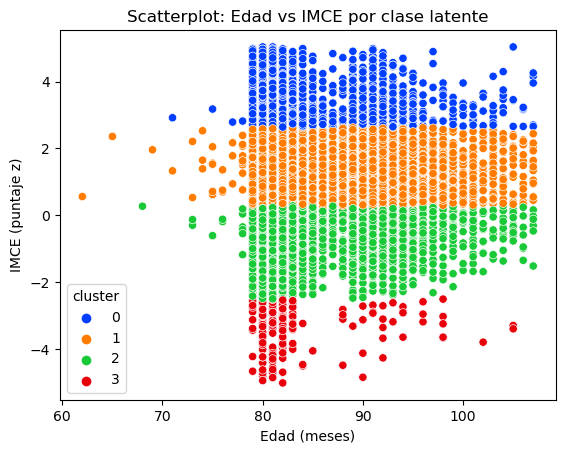

In [58]:
# Grafica de clusters
df_step.groupby('cluster')[['imce', 'act_fisica', 'edad']].mean()

sns.scatterplot(data=df_step, x='edad', y='imce', hue='cluster', palette='bright')
plt.title("Scatterplot: Edad vs IMCE por clase latente")
plt.xlabel("Edad (meses)")
plt.ylabel("IMCE (puntaje z)")
plt.show()

# SEM

Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

**R**: Para la pregunta se uso el modelo base de la pregunta 4, implemetada de acuerdo a los redulatados de la correlación entre factores. A partir de esto se creó otro modelo para el SEM, mas completo, en donde además de mantener la estructura factorial, se incorpora un modelo estrucutral donde los factores latentes explican la variables dependiente IMCE, junto con variables relevantes como sexo, area y actividad física. El modelo al final mostro un buen ajuste de datos, el CFI da 0.931, el TLI da 0.915 y el RMSA da 0.046, lo que indican un buen ajuste, mayores a 0.8 y menor a 0.05. 

In [59]:
mod = """
F1 =~ sk9 + sk10 + sk11 + sk12 + sk13
F2 =~ sk1 + sk2 + sk3 + sk4
F3 =~ sk5 + sk6 + sk8
"""

model = semopy.Model(mod)
out=model.fit(df1)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.140
Number of iterations: 42
Params: 1.336 1.238 1.096 1.262 1.799 1.604 1.783 1.024 1.155 0.158 0.056 0.096 0.054 0.165 0.062 0.099 0.599 0.203 0.446 0.714 0.245 0.201 0.160 0.153 0.375 0.475 0.282


In [60]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,F1,1.000000,0.599606,-,-,-
1,sk10,~,F1,1.335692,0.566231,0.017806,75.014439,0.0
2,sk11,~,F1,1.237678,0.738179,0.01415,87.468156,0.0
3,sk12,~,F1,1.095702,0.546815,0.014979,73.150313,0.0
4,sk13,~,F1,1.261839,0.510823,0.01815,69.522107,0.0
5,sk1,~,F2,1.000000,0.594772,-,-,-
6,sk2,~,F2,1.799153,0.646896,0.021867,82.2754,0.0
7,sk3,~,F2,1.604265,0.640740,0.019615,81.788289,0.0
8,sk4,~,F2,1.783453,0.720936,0.02044,87.255114,0.0
9,sk5,~,F3,1.000000,0.720530,-,-,-


In [61]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4309.596189,0.0,86209.718698,0.950564,0.95001,0.935307,0.95001,0.936024,0.052169,53.71908,278.667729,0.14046


In [62]:
cfa1=model.predict_factors(df1)
cfa1.describe()

,F1,F2,F3
count,3.068200e+04,3.068200e+04,3.068200e+04
mean,1.296864e-17,4.677975e-17,3.427427e-17
std,3.514818e-01,2.068787e-01,3.472536e-01
min,-3.351589e-01,-1.533860e-01,-2.993859e-01
25%,-2.573577e-01,-1.382566e-01,-2.633346e-01
50%,-1.088291e-01,-8.282263e-02,-1.226240e-01
75%,1.705905e-01,6.192136e-02,1.472356e-01
max,2.726158e+00,2.002315e+00,2.999691e+00


In [63]:
mod_cf = '''
#Measurement
eta1 =~ sk11 + sk9 + sk10 + sk12           
eta2 =~ sk6 + sk8 + sk5                    
eta3 =~ sk4 + sk2 + sk3 + sk1            

#Structural
imce ~ eta1 + eta2 + eta3 + sexo + area + act_fisica
'''

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(df);
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.186
Number of iterations: 38
Params: 0.803 1.007 0.834 1.127 0.980 1.010 0.901 0.561 -0.027 0.219 -0.150 0.132 -0.146 -0.026 0.257 0.124 0.125 0.173 0.173 0.113 1.867 0.099 0.621 0.188 0.458 0.245 0.201 0.160 0.152 0.375 0.476 0.275


In [64]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,88,108,5691.619564,0.0,81258.790339,0.930948,0.929957,0.914038,0.929957,0.915254,0.045557,63.628993,330.234799,0.185504


In [65]:
model_cfa.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk11,~,eta1,1.000000,0.759605,-,-,-
1,sk9,~,eta1,0.803437,0.613371,0.009282,86.5588,0.0
2,sk10,~,eta1,1.007429,0.543768,0.012797,78.724972,0.0
3,sk12,~,eta1,0.833785,0.529817,0.010827,77.007686,0.0
4,sk6,~,eta2,1.000000,0.561863,-,-,-
5,sk8,~,eta2,1.126844,0.562051,0.016762,67.225145,0.0
6,sk5,~,eta2,0.979916,0.722294,0.013297,73.694709,0.0
7,sk4,~,eta3,1.000000,0.720593,-,-,-
8,sk2,~,eta3,1.009587,0.646722,0.010831,93.214164,0.0
9,sk3,~,eta3,0.900669,0.641054,0.009728,92.584367,0.0


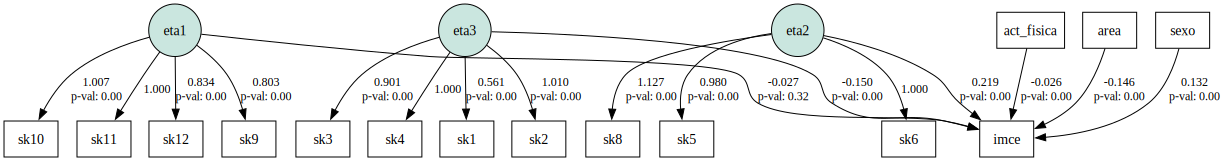

In [66]:
semopy.semplot(model_cfa, "semmodel.png")